In [11]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

In [9]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False


In [3]:
from collections import defaultdict 

method_names = ['EVOS', 'NMT', 'Progressive Stratified Grid Sampling', 'Random', 'Full Training']
run_names = [  'null_', 'random_', 'EVOS', 'NMT', 'cluster_grid',]

# Method name mapping for better display
method_display_names = {
    'EVOS': 'EVOS',
    'NMT': 'NMT', 
    'cluster_grid': 'Cluster Grid',
    'random_': 'Random',
    'null_': 'Full Training'
}

# Total epochs for each method
total_epochs = {
    'EVOS': 5000,
    'NMT': 5000, 
    'cluster_grid': 5000,
    'random_': 5000,
    'null_': 2000
}


In [4]:
for n in run_names:
    locals()[n] = defaultdict(list)

import wandb
import pandas as pd
import numpy as np

# Create API object
api = wandb.Api()

# Replace with your username/entity and project name
entity = "bnl-lemon"
project = "neurips-workshop-inr-sampling"

# Get all runs in the project
runs = api.runs(f"{entity}/{project}")

# Collect run data
time_list, config_list, name_list = [], [], []

for run in runs:
    if "5e-4" in run.name and 'null' not in run.name:
        continue
    for n in run_names:
        if n in run.name:
            locals()[n]['name'].append(run.name)
            locals()[n]['time'].append(np.array(run.history()['Time']))
            locals()[n]['psnr'].append(np.array(run.history()['psnr']))
            locals()[n]['ssim'].append(np.array(run.history()['ssim']))
            locals()[n]['test_rel_loss'].append(np.array(run.history()['test_rel_loss']))
        
    # # Summary metrics (final values)
    # summary_list.append(run.summary._json_dict)
    # # Config parameters
    # config_list.append({k: v for k, v in run.config.items() if not k.startswith('_')})
    # # Run name
    # name_list.append(run.name)

# # Combine into a DataFrame
# df = pd.DataFrame({
#     "name": name_list,
#     "config": config_list,
#     "summary": summary_list
# })

# print(df.head())


In [12]:
from matplotlib import pyplot as plt
import numpy as np

# Set up the figure with proper size and layout
fig1, ax1 = plt.subplots(1, figsize=(10, 8))
fig2, ax2 = plt.subplots(1, figsize = (10, 8))
# fig.suptitle('Training Progress Analysis', fontsize=16, fontweight='bold')

# Adjust spacing between subplots
# plt.subplots_adjust(left=0.08, right=0.95, top=0.92, bottom=0.1, wspace=0.25)

for n in run_names:
    N = total_epochs[n]
    label = method_display_names[n]
    psnr_array = np.stack(locals()[n]['psnr'])
    psnr_array = psnr_array[:, :N//10]
    mean_vals = np.mean(psnr_array, axis=0)
    
    # Plot PSNR vs Epochs
    epochs = np.arange(1, N+1, 10)
    ax1.plot(epochs, mean_vals, label=label, linewidth=2)
    ax1.fill_between(
        epochs,
        psnr_array.min(axis=0),
        psnr_array.max(axis=0),
        alpha=0.2,
    )
    
    # Plot PSNR vs Time
    time_array = np.stack(locals()[n]['time'])
    time_array = time_array[:, :N//10]
    mean_time = time_array.mean(axis=0)
    initial_time = mean_time[0] - (mean_time[-1] - mean_time[0])/(len(mean_time)-1)
    mean_time = mean_time - initial_time
    
    ax2.plot(mean_time, mean_vals, label=label, linewidth=2)
    ax2.fill_between(
        mean_time, 
        psnr_array.min(axis=0),
        psnr_array.max(axis=0), 
        alpha=0.2,
    )

# Configure first subplot (PSNR vs Epochs)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("PSNR (dB)", fontsize=12)
# ax1.set_title("PSNR vs Training Epochs", fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 5000])
# ax1.tick_params(axis='both', which='major', labelsize=10)

# Configure second subplot (PSNR vs Time)
ax2.set_xlabel("Training Time (seconds)", fontsize=12)
ax2.set_ylabel("PSNR (dB)", fontsize=12)
ax2.set_title("PSNR vs Training Time", fontsize=14, fontweight='bold')
ax2.legend(loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 20])
ax2.tick_params(axis='both', which='major', labelsize=10)

# Save as PDF with high quality
fig1.savefig('trainepoch.png', 
           format='png', 
           dpi=300, 
           bbox_inches='tight',
           facecolor='white',
           edgecolor='none')

# Also save as PNG for quick viewing
fig2.savefig('traintime.png', 
           format='png', 
           dpi=300, 
           bbox_inches='tight',
           facecolor='white',
           edgecolor='none')

plt.show()

print("Plots saved as 'training_analysis.pdf' and 'training_analysis.png'")

RuntimeError: Failed to process string with tex because latex could not be found

Error in callback <function _draw_all_if_interactive at 0x7fb619d4a320> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 6000x4800 with 1 Axes>

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 6000x4800 with 1 Axes>

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


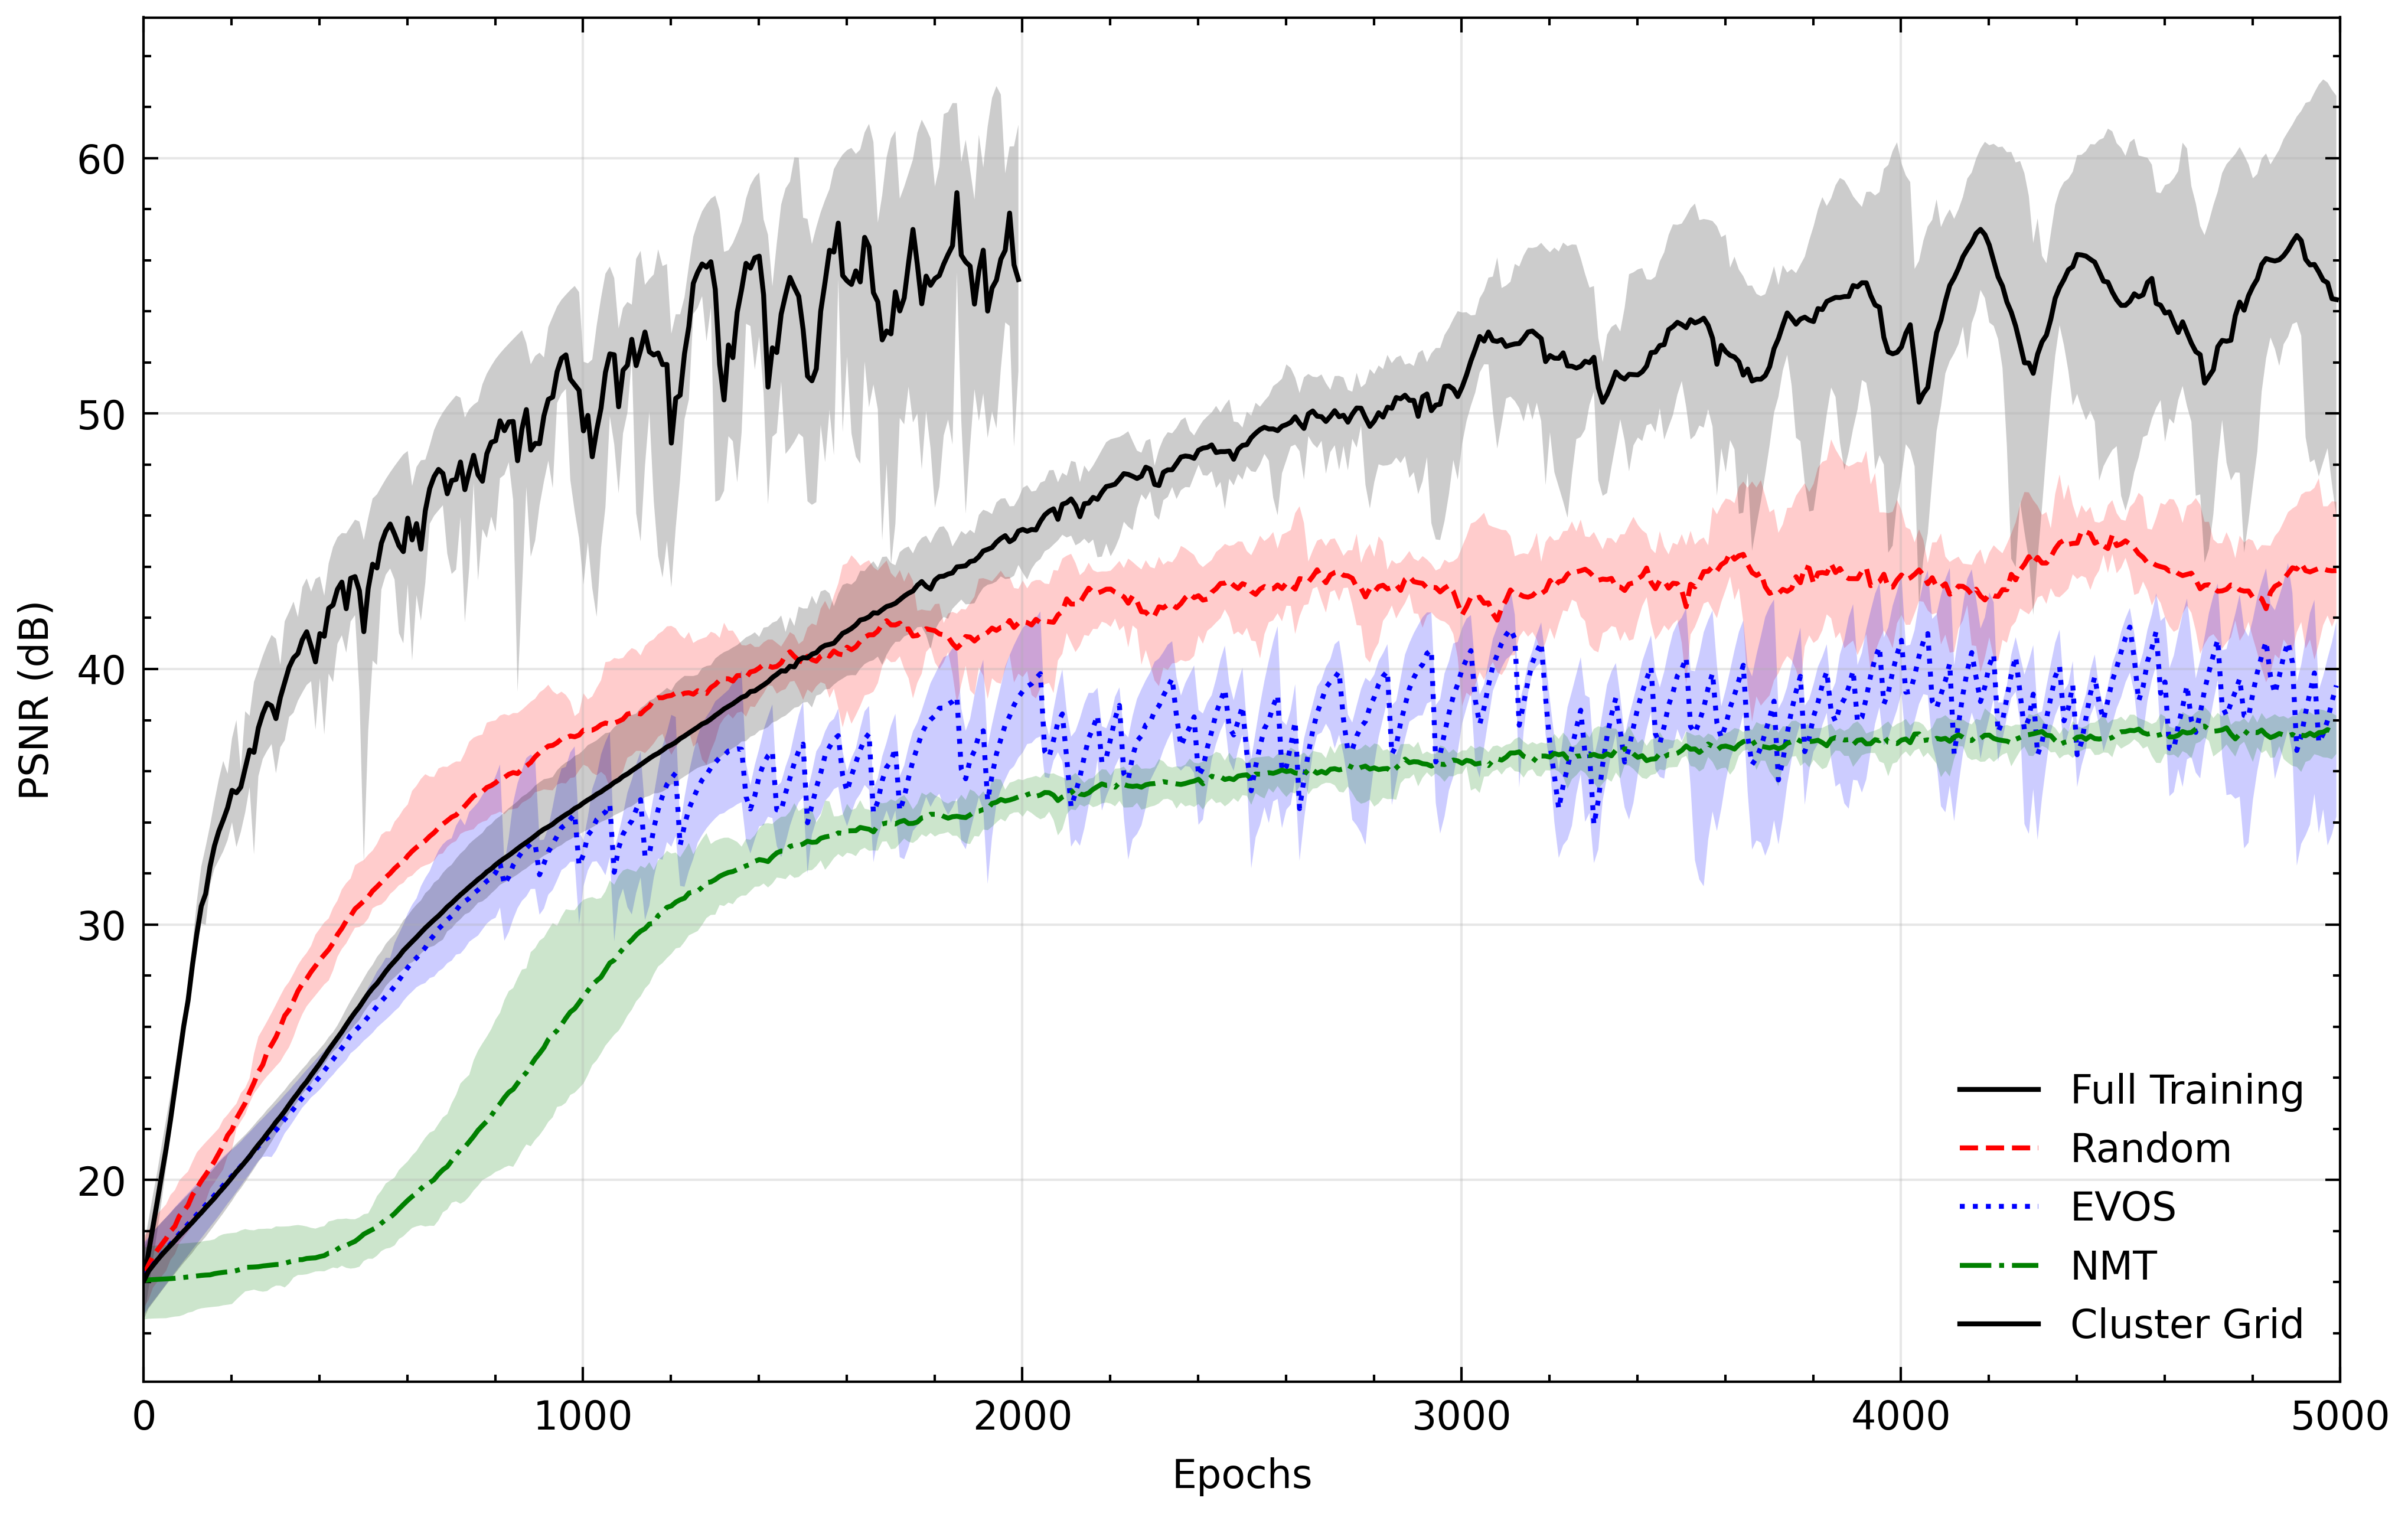

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


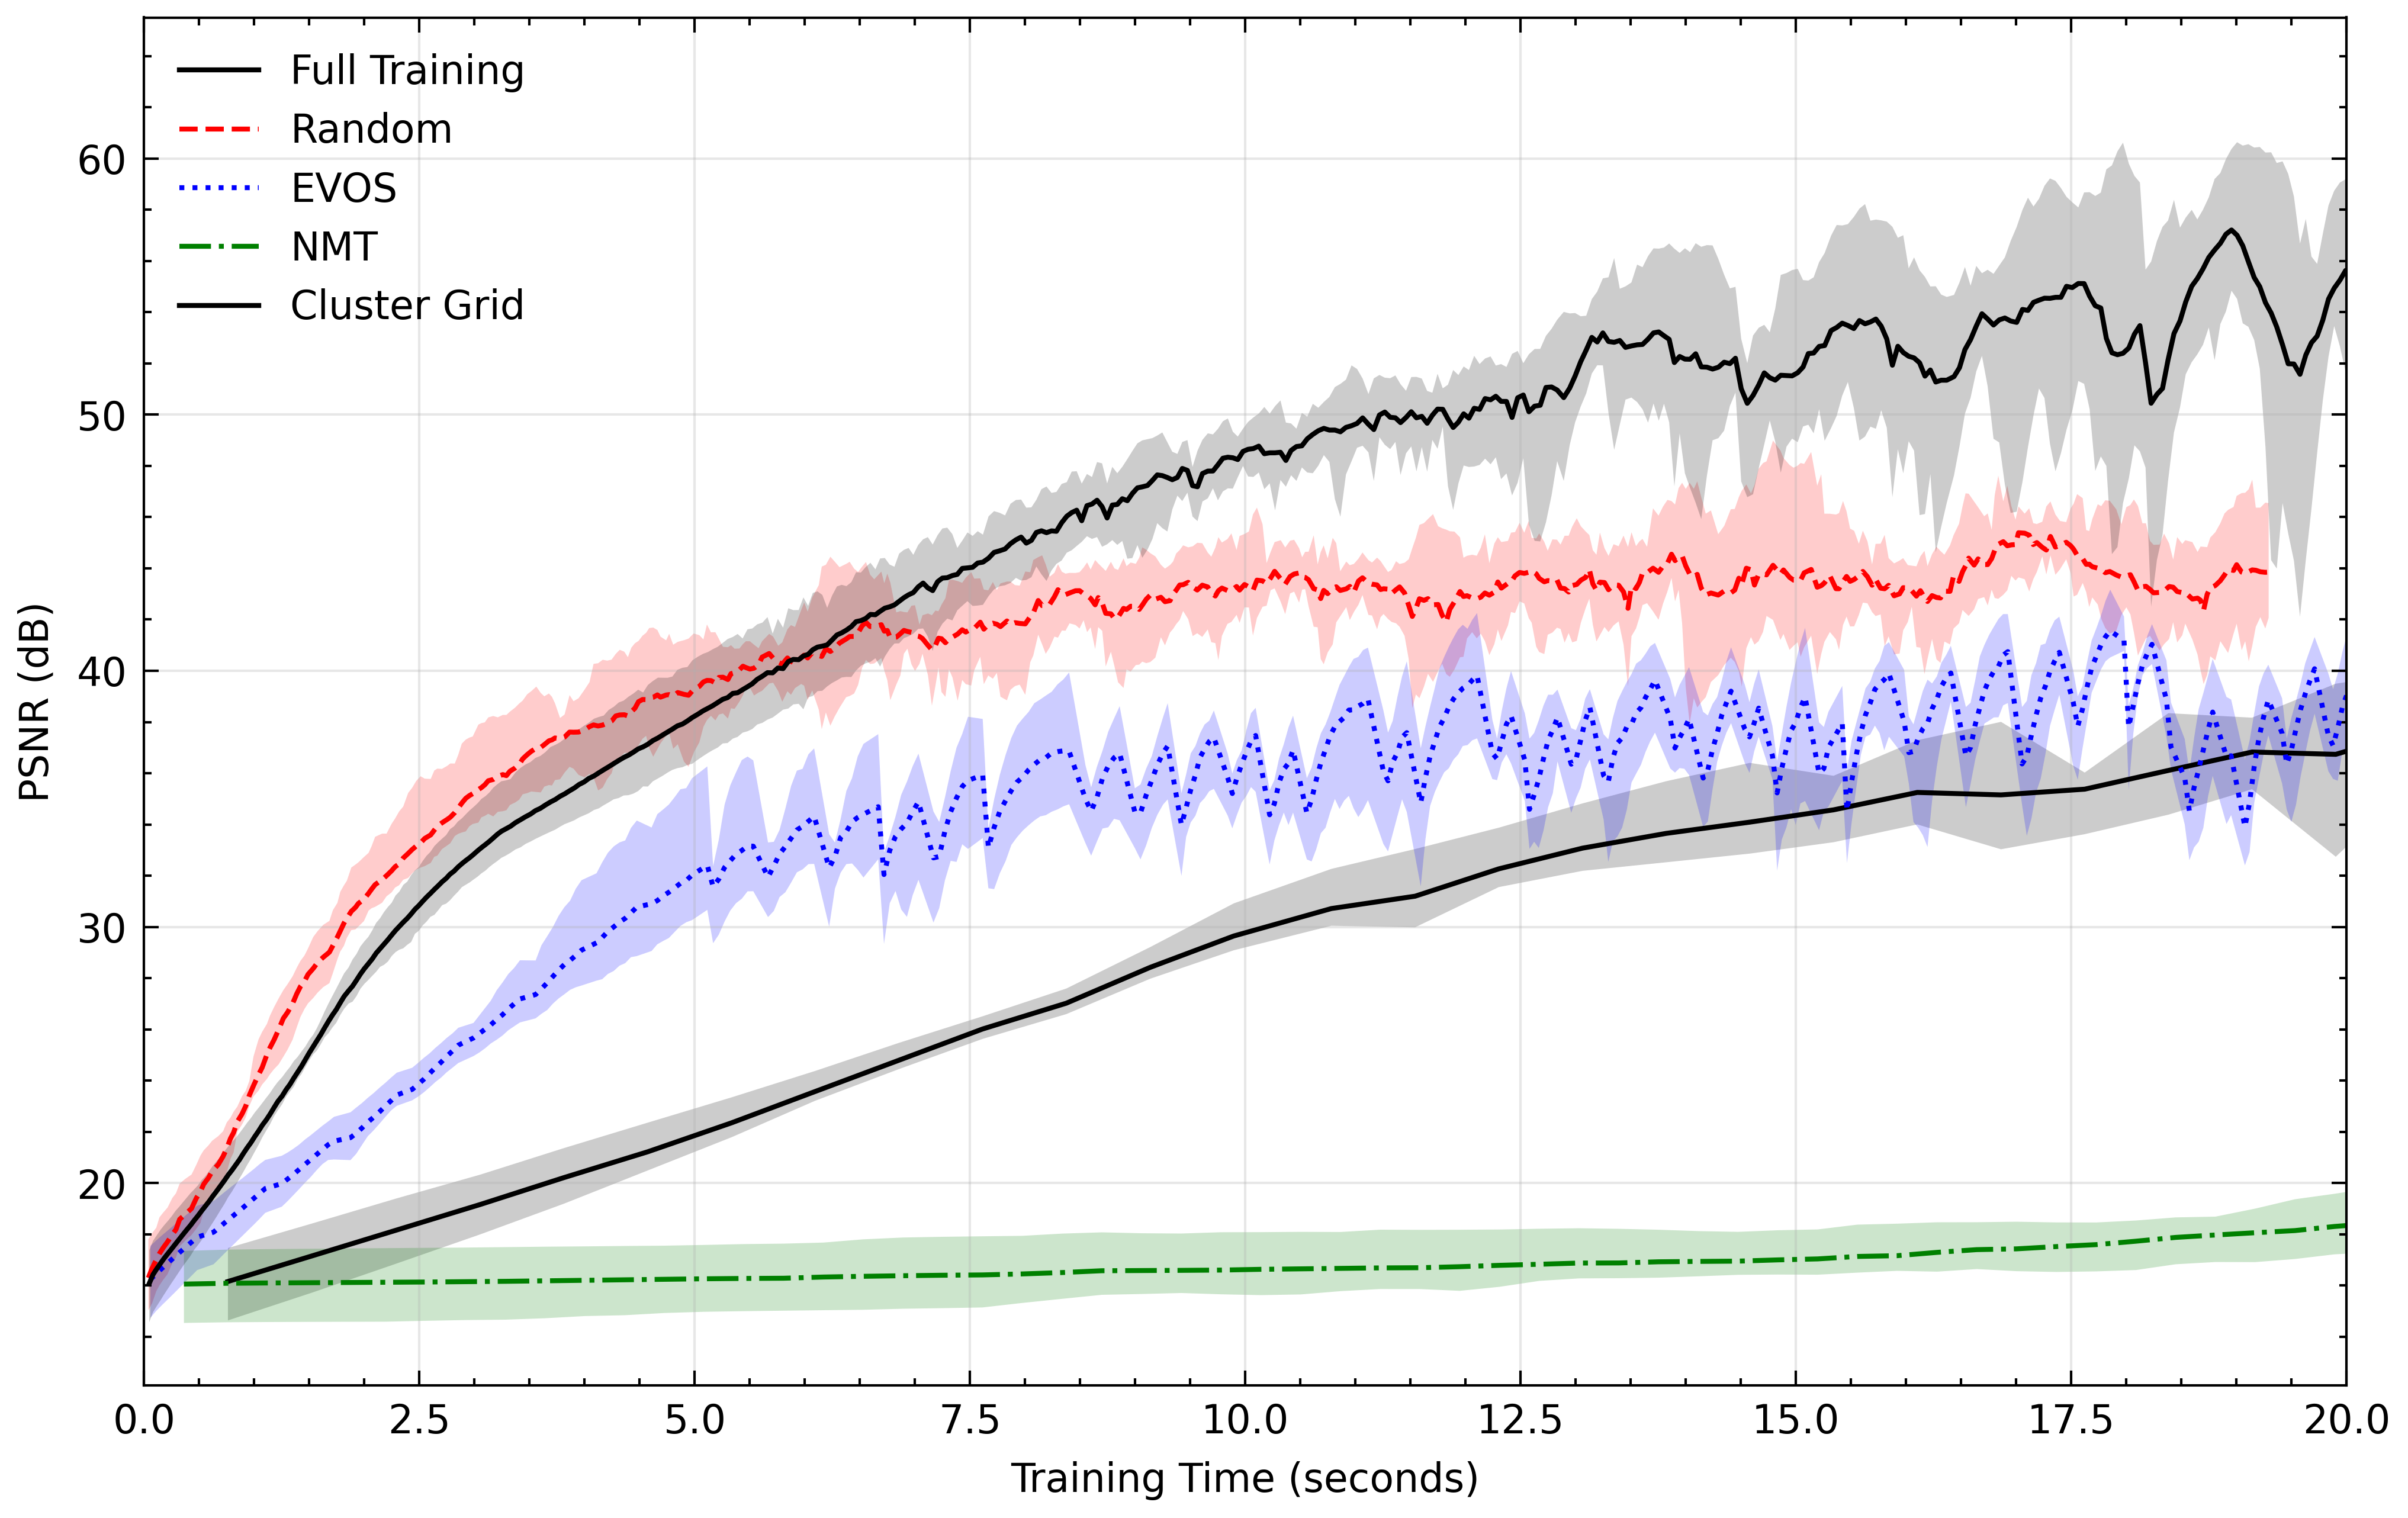

In [6]:
plt.style.use(['science','ieee'])
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
fig1, ax1 = plt.subplots(figsize = (8, 5))
fig2, ax2 = plt.subplots(figsize = (8, 5))

for n in run_names:
    N = total_epochs[n]
    label = method_display_names[n]
    psnr_array = np.stack(locals()[n]['psnr'])
    psnr_array = psnr_array[:, :N//10]
    mean_vals = np.mean(psnr_array, axis=0)
    ax1.plot(np.arange(1, N+1, 10), mean_vals, label=label)
    ax1.fill_between(
        np.arange(1, N+1, 10),
        psnr_array.min(axis=0),
        psnr_array.max(axis=0),
        alpha=0.2,
    )
    
    time_array = np.stack(locals()[n]['time'])
    time_array = time_array[:, :N//10]
    mean_time = time_array.mean(axis=0)
    initial_time = mean_time[0] - (mean_time[-1] - mean_time[0])/(len(mean_time)-1)
    mean_time = mean_time - initial_time
    ax2.plot(mean_time, mean_vals, label=label)
    ax2.fill_between(
        mean_time, 
        psnr_array.min(axis=0),
        psnr_array.max(axis=0), 
        alpha = 0.2,
    )


    
    
ax1.set_xlabel("Epochs")
ax1.set_ylabel("PSNR (dB)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 5000])


ax2.set_xlabel("Training Time (seconds)")
ax2.set_ylabel("PSNR (dB)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 20])

fig1.savefig('trainepoch.png', 
           format='png', 
           dpi=300, 
           bbox_inches='tight',
           facecolor='white',
           edgecolor='none')

# Also save as PNG for quick viewing
fig2.savefig('traintime.png', 
           format='png', 
           dpi=300, 
           bbox_inches='tight',
           facecolor='white',
           edgecolor='none')

plt.show()



In [7]:
import numpy as np

def generate_latex_table(run_names, locals_dict, target_time=20):
    """
    Generate LaTeX table showing method comparison at a specific time point.
    
    Args:
        run_names: List of method names
        locals_dict: Dictionary containing the experiment data
        target_time: Time point to extract results from (default: 20)
    """
    
    
    
    
    
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\begin{tabular}{|l|c|c|c|c|}")
    print("\\hline")
    print("\\textbf{Method} & \\textbf{PSNR} & \\textbf{SSIM} & \\textbf{Rel RMSE} & \\textbf{Avg Time/Epoch (s)} \\\\")
    print("\\hline")
    
    # First pass: collect all metrics to find the best values
    all_metrics = {'psnr': [], 'ssim': [], 'test_rel_loss': []}
    method_results = {}
    
    for method in run_names:
        if method not in locals_dict or len(locals_dict[method]['time']) == 0:
            continue
            
        psnr_values = []
        ssim_values = []
        test_rel_loss_values = []
        avg_epoch_times = []
        
        # Extract values at target_time for each run
        for i in range(len(locals_dict[method]['time'])):
            time_array = locals_dict[method]['time'][i]
            psnr_array = locals_dict[method]['psnr'][i]
            ssim_array = locals_dict[method]['ssim'][i]
            test_rel_loss_array = locals_dict[method]['test_rel_loss'][i]
            
            # Find the index closest to target_time
            if len(time_array) > 0:
                closest_idx = np.argmin(np.abs(time_array - target_time))
                
                # Only include if the time is reasonably close to target
                if np.abs(time_array[closest_idx] - target_time) <= 1.0:  # tolerance of 1 time unit
                    psnr_values.append(psnr_array[closest_idx])
                    ssim_values.append(ssim_array[closest_idx])
                    test_rel_loss_values.append(test_rel_loss_array[closest_idx])
                
                # Calculate average time per epoch for this run
                if len(time_array) > 1:
                    total_time = time_array[-1] - time_array[0] if len(time_array) > 0 else 0
                    epochs = total_epochs.get(method, 5000)
                    avg_time_per_epoch = total_time / epochs if epochs > 0 else 0
                    avg_epoch_times.append(avg_time_per_epoch)
        
        # Store method results
        if len(psnr_values) > 0:
            psnr_mean = np.mean(psnr_values)
            ssim_mean = np.mean(ssim_values)
            test_rel_loss_mean = np.mean(test_rel_loss_values)
            avg_epoch_time = np.mean(avg_epoch_times) if avg_epoch_times else 0
            
            method_results[method] = {
                'psnr_mean': psnr_mean,
                'psnr_std': np.std(psnr_values),
                'ssim_mean': ssim_mean,
                'ssim_std': np.std(ssim_values),
                'test_rel_loss_mean': test_rel_loss_mean,
                'test_rel_loss_std': np.std(test_rel_loss_values),
                'avg_epoch_time': avg_epoch_time,
                'avg_epoch_time_std': np.std(avg_epoch_times) if avg_epoch_times else 0
            }
            
            # Store for finding best values
            all_metrics['psnr'].append(psnr_mean)
            all_metrics['ssim'].append(ssim_mean)
            all_metrics['test_rel_loss'].append(test_rel_loss_mean)
    
    # Find best values (highest for PSNR and SSIM, lowest for test_rel_loss)
    best_psnr = max(all_metrics['psnr']) if all_metrics['psnr'] else None
    best_ssim = max(all_metrics['ssim']) if all_metrics['ssim'] else None
    best_test_rel_loss = min(all_metrics['test_rel_loss']) if all_metrics['test_rel_loss'] else None
    
    # Second pass: print results with bold formatting for best values
    for method in run_names:
        if method not in method_results:
            method_name = method_display_names.get(method, method)
            print(f"{method_name} & N/A & N/A & N/A & N/A \\\\")
            continue
        
        results = method_results[method]
        method_name = method_display_names.get(method, method)
        
        # Format values, making best ones bold
        psnr_str = f"{results['psnr_mean']:.2f} $\\pm$ {results['psnr_std']:.2f}"
        if abs(results['psnr_mean'] - best_psnr) < 1e-6:  # Check if this is the best
            psnr_str = f"\\textbf{{{psnr_str}}}"
            
        ssim_str = f"{results['ssim_mean']:.3f} $\\pm$ {results['ssim_std']:.3f}"
        if abs(results['ssim_mean'] - best_ssim) < 1e-6:
            ssim_str = f"\\textbf{{{ssim_str}}}"
            
        test_rel_loss_str = f"{results['test_rel_loss_mean']:.3f} $\\pm$ {results['test_rel_loss_std']:.3f}"
        if abs(results['test_rel_loss_mean'] - best_test_rel_loss) < 1e-6:
            test_rel_loss_str = f"\\textbf{{{test_rel_loss_str}}}"
        
        avg_time_str = f"{results['avg_epoch_time']:.3f} $\\pm$ {results['avg_epoch_time_std']:.3f}"
        
        print(f"{method_name} & {psnr_str} & {ssim_str} & {test_rel_loss_str} & {avg_time_str} \\\\")
    
    print("\\hline")
    print("\\end{tabular}")
    print(f"\\caption{{Performance comparison of different methods at time = {target_time}. Best values are shown in bold.}}")
    print("\\label{tab:method_comparison}")
    print("\\end{table}")



In [8]:
generate_latex_table(run_names, locals())

\begin{table}[h!]
\centering
\begin{tabular}{|l|c|c|c|c|}
\hline
\textbf{Method} & \textbf{PSNR} & \textbf{SSIM} & \textbf{Rel RMSE} & \textbf{Avg Time/Epoch (s)} \\
\hline
Full Training & 37.58 $\pm$ 1.46 & 0.976 $\pm$ 0.024 & 0.093 $\pm$ 0.030 & 0.190 $\pm$ 0.000 \\
Random & 44.48 $\pm$ 1.72 & 0.982 $\pm$ 0.006 & 0.041 $\pm$ 0.012 & 0.004 $\pm$ 0.000 \\
EVOS & 37.41 $\pm$ 1.70 & 0.930 $\pm$ 0.017 & 0.087 $\pm$ 0.017 & 0.006 $\pm$ 0.000 \\
NMT & 18.35 $\pm$ 0.88 & 0.211 $\pm$ 0.095 & 0.776 $\pm$ 0.111 & 0.036 $\pm$ 0.000 \\
Cluster Grid & \textbf{56.23 $\pm$ 2.72} & \textbf{0.998 $\pm$ 0.001} & \textbf{0.010 $\pm$ 0.003} & 0.005 $\pm$ 0.000 \\
\hline
\end{tabular}
\caption{Performance comparison of different methods at time = 20. Best values are shown in bold.}
\label{tab:method_comparison}
\end{table}


In [3]:
run.history()

,Time,psnr,test_loss,train_rel_loss,ssim,_runtime,_timestamp,train_loss,_step,test_rel_loss
0,0.459452,17.549164,28.926556,0.974325,0.001904,4.730480,1.755282e+09,216.653687,10,0.976502
1,0.510752,17.758789,27.563484,0.965602,0.007296,4.933698,1.755282e+09,212.107574,20,0.953217
2,0.564223,17.962273,26.301836,0.957289,0.015429,5.135529,1.755282e+09,208.756653,30,0.931146
3,0.616634,18.153378,25.169538,0.948619,0.027493,5.337400,1.755282e+09,205.653229,40,0.910883
4,0.669557,18.348587,24.063263,0.940358,0.042426,5.539310,1.755282e+09,201.997498,50,0.890640
...,...,...,...,...,...,...,...,...,...,...
495,29.142110,33.573982,0.722462,0.149120,0.852598,101.856838,1.755283e+09,0.775498,4960,0.154324
496,29.184635,34.812206,0.543241,0.109165,0.873633,102.034710,1.755283e+09,0.405353,4970,0.133820
497,29.227265,35.717693,0.441005,0.098420,0.890755,102.212590,1.755283e+09,0.324557,4980,0.120572
498,29.270730,36.517002,0.366871,0.076177,0.902535,102.385773,1.755283e+09,0.211765,4990,0.109972


In [4]:
np.array(run.history()['psnr'])

array([17.54916382, 17.75878906, 17.96227264, 18.15337753, 18.34858704,
       18.54076385, 18.73326492, 18.92741585, 19.11825943, 19.30341339,
       19.48255157, 19.6668911 , 19.84537315, 20.02462196, 20.19024086,
       20.37125015, 20.54859161, 20.74001503, 20.90633392, 21.06831741,
       21.19442368, 21.34326935, 21.5054493 , 21.70199394, 21.87206268,
       22.05539894, 22.24125862, 22.40675735, 22.58878899, 22.76467514,
       22.9503746 , 23.12657547, 23.32901192, 23.51057816, 23.71952057,
       23.9081955 , 24.1164608 , 24.31078148, 24.50341415, 24.69208145,
       24.88889503, 25.0655632 , 25.27754974, 25.46660233, 25.67167282,
       25.84833527, 26.06467438, 26.25341797, 26.4127388 , 26.55834961,
       26.61534119, 26.69925308, 26.89411926, 27.16179848, 27.37284851,
       27.53553772, 27.75823212, 27.87103844, 28.05570793, 28.31541824,
       28.38166046, 28.4514637 , 28.51948929, 28.59114647, 28.79855919,
       29.07761002, 29.24764824, 29.42713165, 29.62370872, 29.93